In [9]:
import numpy as np 
import matplotlib.pyplot as plt
import pyana

In [15]:
spectrum_to_fit = pyana.fzread('/home/milic/codes/snapi/test_inv/cube_to_invert.f0')['data']
spectrum_to_fit.shape

(1, 1, 4, 51)

In [23]:
fit = pyana.fzread('/home/milic/codes/snapi/test_inv/inverted_spectra.f0')['data']
fit.shape

(1, 1, 4, 51)

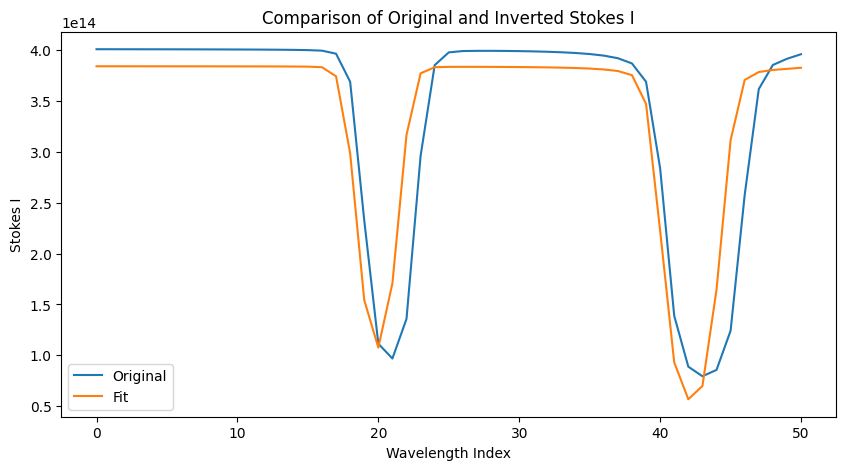

In [24]:
# Compare Stokes I fits real quick
plt.figure(figsize=(10,5))
plt.plot(spectrum_to_fit[0,0,0,:], label='Original')
plt.plot(fit[0,0,0,:], label='Fit')
plt.legend()
plt.xlabel('Wavelength Index')
plt.ylabel('Stokes I')
plt.title('Comparison of Original and Inverted Stokes I')
plt.show()

In [19]:
inv_atmos = pyana.fzread('/home/milic/codes/snapi/test_inv/inverted_atmos.f0')['data']
inv_atmos.shape

(12, 1, 1, 61)

In [6]:
# 0 - tau 
# 1 - z (does not actually make sense in inversion mode)
# 2 - T 
# 3 - pressure (which is actually inferred under the assumption of hydrostatic equilibrium, so it is not a free parameter in the inversion)
# 4 - electron pressure (inferred from the temperature and pressure under the assumption of LTE)
# 5 - I don't even know does not matter
# 6 - same 
# 7 - magnetic field, which we also don't care about now 
# 8 - microturbulence, which in ideal case should be zero, because we want to infer detailed depth stratification of the velocities
# 9 - LOS velocity 
# 10 - magnetic field inclination, which we also don't care about now
# 11 - magnetic field azimuth, which we also don't care about now

In [21]:
# Let's actually load the original atmosphere used to generate this data and see what the agreement between the two looks like:
atmos_og = np.loadtxt('/home/milic/codes/snapi/test_inv/falc_61.dat',skiprows=1,unpack=True)
atmos_og.shape

(12, 61)

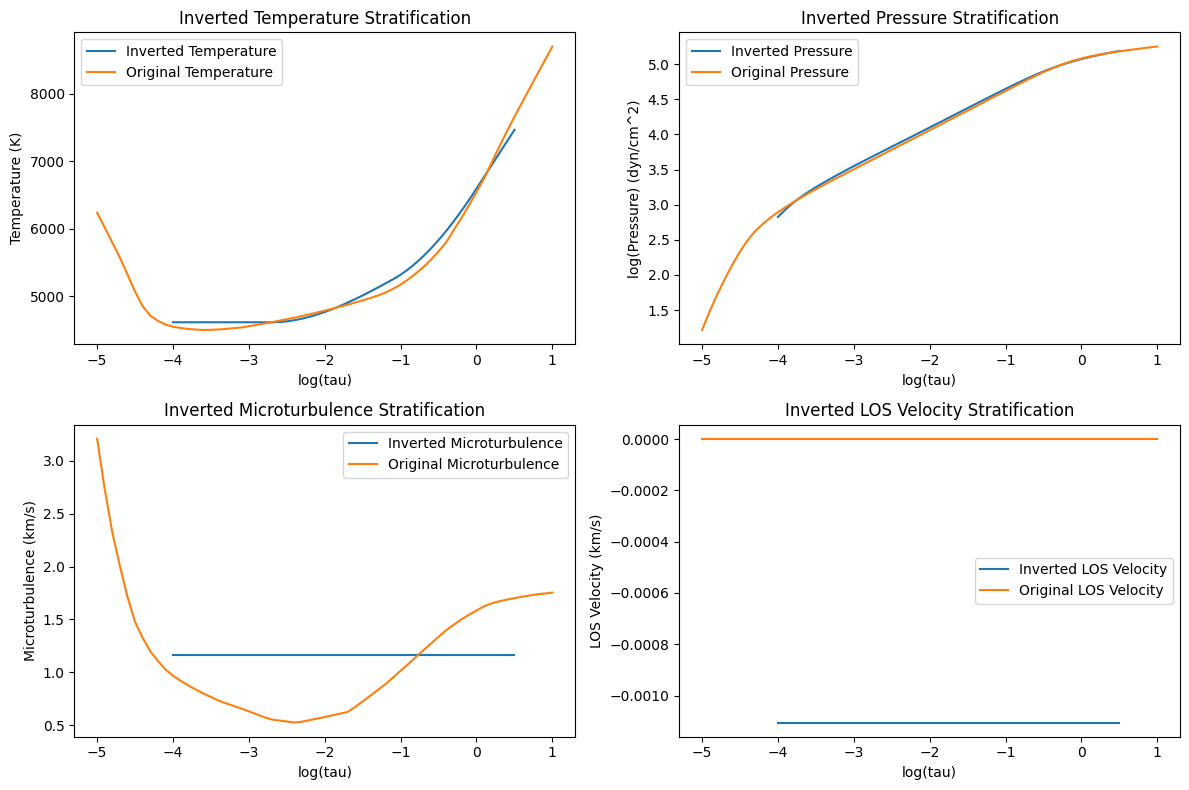

In [22]:
# Let's just plot temperature, pressure, microturbulence and los velocity, take care about units, so plot pressure in log scale and velocities should 
# be converted to km/s from cm/s, also swap side of the los velocity

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(inv_atmos[0,0,0,:], inv_atmos[2,0,0,:], label='Inverted Temperature')
plt.plot(atmos_og[0,:], atmos_og[2,:], label='Original Temperature')
plt.xlabel('log(tau)')
plt.ylabel('Temperature (K)')
plt.title('Inverted Temperature Stratification')
plt.legend()
plt.subplot(2,2,2)
plt.plot(inv_atmos[0,0,0,:], np.log10(inv_atmos[3,0,0,:]), label='Inverted Pressure')
plt.plot(atmos_og[0,:], np.log10(atmos_og[3,:]), label='Original Pressure')
plt.xlabel('log(tau)')
plt.ylabel('log(Pressure) (dyn/cm^2)')
plt.title('Inverted Pressure Stratification')
plt.legend()
plt.subplot(2,2,3)
plt.plot(inv_atmos[0,0,0,:], inv_atmos[8,0,0,:]/1e5, label='Inverted Microturbulence')
plt.plot(atmos_og[0,:], atmos_og[8,:]/1e5, label='Original Microturbulence')
plt.xlabel('log(tau)')
plt.ylabel('Microturbulence (km/s)')
plt.title('Inverted Microturbulence Stratification')
plt.legend()
plt.subplot(2,2,4)
plt.plot(inv_atmos[0,0,0,:], -inv_atmos[9,0,0,:]/1e5, label='Inverted LOS Velocity')
plt.plot(atmos_og[0,:], -atmos_og[9,:]/1e5, label='Original LOS Velocity')
plt.xlabel('log(tau)')
plt.ylabel('LOS Velocity (km/s)')
plt.title('Inverted LOS Velocity Stratification')
plt.legend()
plt.tight_layout()